In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

In [2]:
import os

print(os.getcwd())

C:\Users\SATYA\OneDrive\Desktop\Week2-Work-Data-Validation\notebooks


In [3]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'anomaly_summary_by_category.csv', 'Data_Validation.ipynb', 'monthly_demand_clean_long.csv']


In [4]:
import pandas as pd

# Load the Week 1 output (wide format: date x category)
wide = pd.read_csv(
    "../data/monthly_demand_clean.csv",
    index_col=0,
    parse_dates=True
)

# Rename the index
wide.index.name = "Date"

# Display information
print("Shape:", wide.shape)
print("Categories found:", list(wide.columns))

# Show first 5 rows
wide.head()

Shape: (54, 5)
Categories found: ['CPU', 'Mother Board', 'RAM', 'Storage', 'Video Card']


,CPU,Mother Board,RAM,Storage,Video Card
Date,,,,,
2013-06-01,NaN,NaN,NaN,119.0,NaN
2013-07-01,NaN,NaN,NaN,0.0,NaN
2013-08-01,NaN,NaN,NaN,0.0,NaN
2013-09-01,NaN,NaN,NaN,0.0,NaN
2013-10-01,NaN,NaN,NaN,0.0,NaN


In [5]:
# Create the "long" version yourself since Week 1 didn't export it
long_df = wide.reset_index().melt(
    id_vars="Date", var_name="CategoryName", value_name="Demand"
)
long_df = long_df.sort_values(["CategoryName", "Date"]).reset_index(drop=True)

# Save it so your teammates can use it too
long_df.to_csv("monthly_demand_clean_long.csv", index=False)

print("Long shape:", long_df.shape)
long_df.head()

Long shape: (270, 3)


,Date,CategoryName,Demand
0,2013-06-01,CPU,NaN
1,2013-07-01,CPU,NaN
2,2013-08-01,CPU,NaN
3,2013-09-01,CPU,NaN
4,2013-10-01,CPU,NaN


In [6]:
# Verify category counts — every category should have the SAME number of months
# (because Week 1 built a complete monthly timeline for every category)
counts = long_df.groupby("CategoryName")["Date"].count()
print(counts)

expected_months = wide.shape[0]
assert (counts == expected_months).all(), "Some categories are missing months!"
print(f"✅ All {len(counts)} categories have {expected_months} months each.")

CategoryName
CPU             54
Mother Board    54
RAM             54
Storage         54
Video Card      54
Name: Date, dtype: int64
✅ All 5 categories have 54 months each.


In [7]:
# 1. Duplicate months per category (there should be ZERO)
dupes = long_df[long_df.duplicated(subset=["CategoryName", "Date"], keep=False)]
print("Duplicate rows found:", len(dupes))
dupes

Duplicate rows found: 0


,Date,CategoryName,Demand


In [8]:
# 2. Negative demand values (impossible in real life — flag if found)
negatives = long_df[long_df["Demand"] < 0]
print("Negative demand rows found:", len(negatives))
negatives

Negative demand rows found: 0


,Date,CategoryName,Demand


In [9]:
# 3. Remaining missing values (leading/trailing gaps Week 1 intentionally left)
missing = long_df[long_df["Demand"].isna()]
print("Missing rows found:", len(missing))
print(missing.groupby("CategoryName").size())
missing

Missing rows found: 96
CategoryName
CPU             23
Mother Board    23
RAM             27
Video Card      23
dtype: int64


,Date,CategoryName,Demand
0,2013-06-01,CPU,NaN
1,2013-07-01,CPU,NaN
2,2013-08-01,CPU,NaN
3,2013-09-01,CPU,NaN
4,2013-10-01,CPU,NaN
...,...,...,...
234,2014-12-01,Video Card,NaN
235,2015-01-01,Video Card,NaN
236,2015-02-01,Video Card,NaN
237,2015-03-01,Video Card,NaN


In [10]:
# Extra check: are all remaining missing values at the START or END of each series (expected),
# or somewhere in the MIDDLE (a bug)?
def check_gap_position(group):
    group = group.sort_values("Date").reset_index(drop=True)
    na_idx = group[group["Demand"].isna()].index
    if len(na_idx) == 0:
        return "no gaps"
    n = len(group)
    if all(i < n * 0.15 or i > n * 0.85 for i in na_idx):
        return "edges only (expected)"
    return "⚠️ MIDDLE gap — investigate"

gap_report = long_df.groupby("CategoryName").apply(check_gap_position)
print(gap_report)

CategoryName
CPU             ⚠️ MIDDLE gap — investigate
Mother Board    ⚠️ MIDDLE gap — investigate
RAM             ⚠️ MIDDLE gap — investigate
Storage                             no gaps
Video Card      ⚠️ MIDDLE gap — investigate
dtype: str


In [11]:
import pandas as pd

# Ensure Date is datetime
long_df["Date"] = pd.to_datetime(long_df["Date"])

# Remove missing demand values
long_df = long_df.dropna(subset=["Demand"]).copy()

# Calculate Q1, Q3 and IQR for each category
Q1 = long_df.groupby("CategoryName")["Demand"].transform(lambda x: x.quantile(0.25))
Q3 = long_df.groupby("CategoryName")["Demand"].transform(lambda x: x.quantile(0.75))

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Flag anomalies
long_df["is_anomaly"] = (
    (long_df["Demand"] < lower) |
    (long_df["Demand"] > upper)
)

# Get anomaly rows
anomalies = (
    long_df[long_df["is_anomaly"]]
    .sort_values(["CategoryName", "Date"])
    .reset_index(drop=True)
)

print(f"Found {len(anomalies)} anomaly points")

anomalies.head(20)

Found 8 anomaly points


,Date,CategoryName,Demand,is_anomaly
0,2016-06-01,Mother Board,557.0,True
1,2017-02-01,Mother Board,393.0,True
2,2016-06-01,RAM,233.0,True
3,2017-02-01,RAM,334.0,True
4,2016-02-01,Storage,434.0,True
5,2016-06-01,Storage,474.0,True
6,2016-11-01,Storage,449.0,True
7,2017-02-01,Storage,870.0,True


In [12]:
print(long_df.columns)
print(long_df.columns)
print(long_df.head())

Index(['Date', 'CategoryName', 'Demand', 'is_anomaly'], dtype='str')
Index(['Date', 'CategoryName', 'Demand', 'is_anomaly'], dtype='str')
         Date CategoryName  Demand  is_anomaly
22 2015-04-01          CPU   402.0       False
23 2015-05-01          CPU   300.0       False
24 2015-06-01          CPU     0.0       False
25 2015-07-01          CPU     0.0       False
26 2015-08-01          CPU     0.0       False


In [13]:
summary = (
    anomalies.groupby("CategoryName")
    .agg(
        anomaly_count=("Demand", "size"),
        avg_anomaly_value=("Demand", "mean"),
        min_anomaly_value=("Demand", "min"),
        max_anomaly_value=("Demand", "max"),
    )
    .reset_index()
)
total_months = long_df.groupby("CategoryName").size().rename("total_months")
summary = summary.merge(total_months, on="CategoryName")
summary["anomaly_rate_%"] = (summary["anomaly_count"] / summary["total_months"] * 100).round(1)
summary

,CategoryName,anomaly_count,avg_anomaly_value,min_anomaly_value,max_anomaly_value,total_months,anomaly_rate_%
0,Mother Board,2,475.00,393.0,557.0,31,6.5
1,RAM,2,283.50,233.0,334.0,27,7.4
2,Storage,4,556.75,434.0,870.0,54,7.4


In [14]:
summary.to_csv("anomaly_summary_by_category.csv", index=False)

In [15]:
print(long_df["is_anomaly"].value_counts())

is_anomaly
False    166
True       8
Name: count, dtype: int64


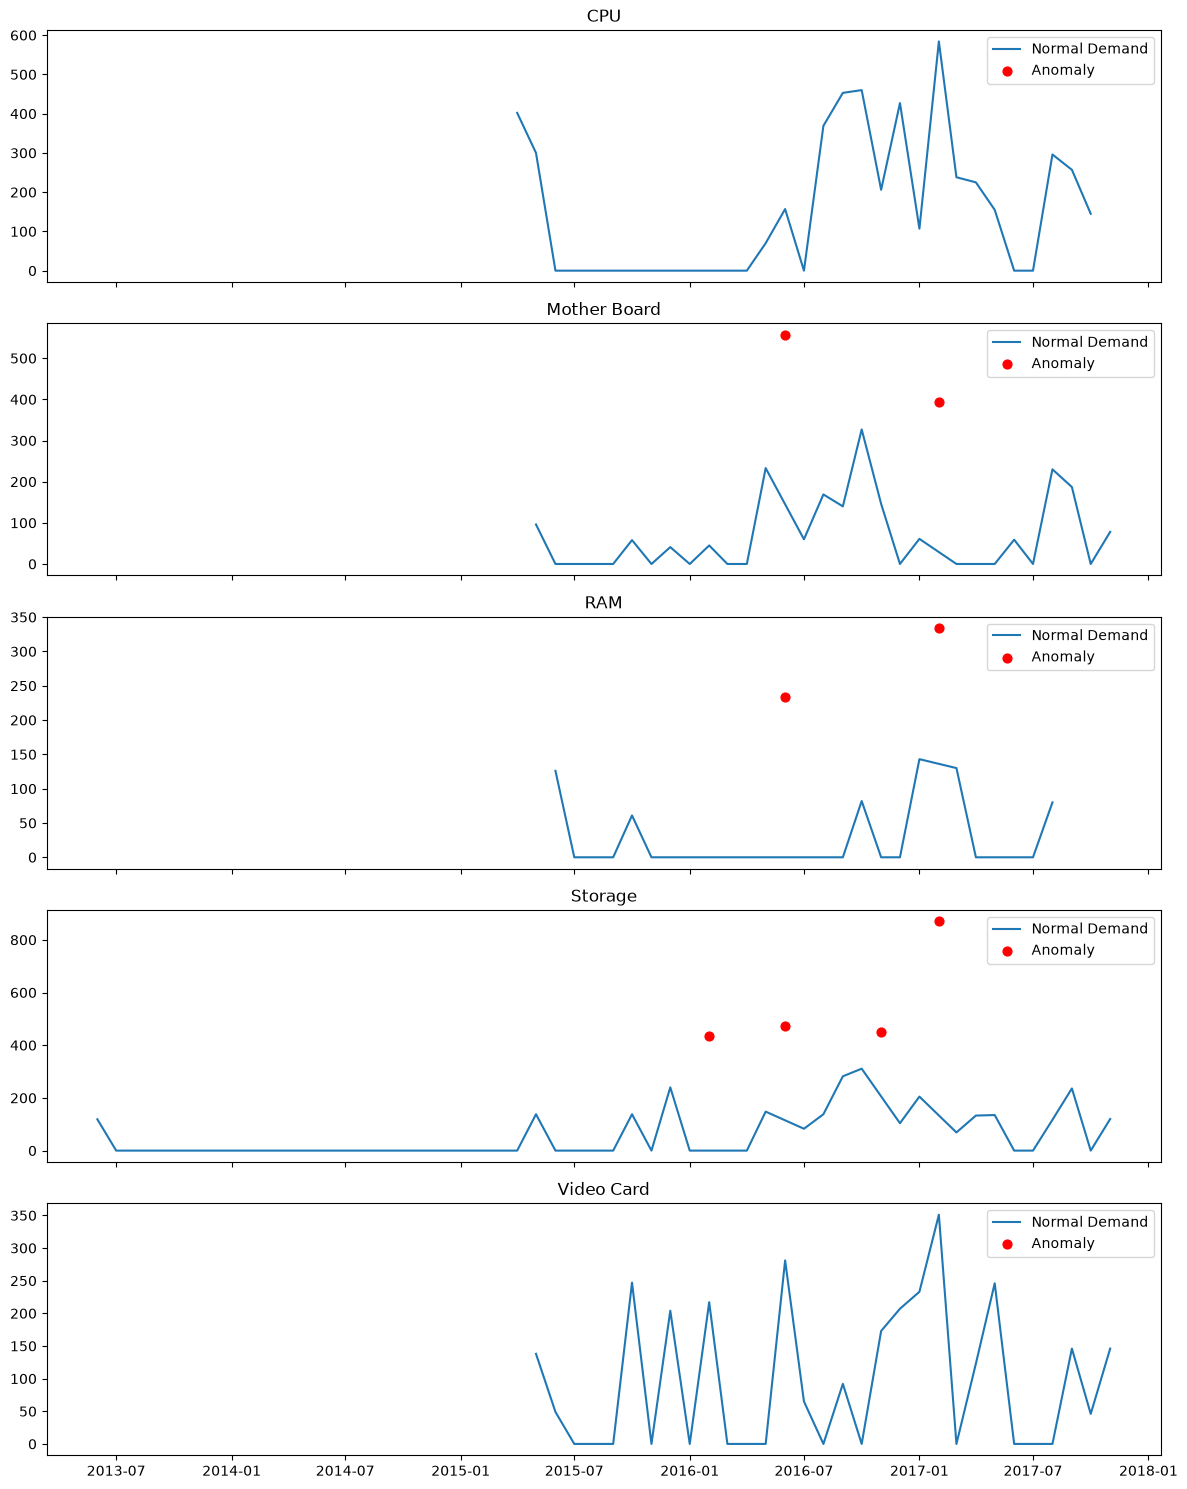

In [16]:
import matplotlib.pyplot as plt

categories = long_df["CategoryName"].unique()

fig, axes = plt.subplots(
    len(categories),
    1,
    figsize=(12, 3 * len(categories)),
    sharex=True
)

# If only one category exists
if len(categories) == 1:
    axes = [axes]

for ax, cat in zip(axes, categories):

    # Use long_df instead of flagged
    sub = long_df[long_df["CategoryName"] == cat].sort_values("Date")

    normal = sub[~sub["is_anomaly"]]
    anom = sub[sub["is_anomaly"]]

    ax.plot(
        normal["Date"],
        normal["Demand"],
        label="Normal Demand"
    )

    ax.scatter(
        anom["Date"],
        anom["Demand"],
        color="red",
        s=40,
        label="Anomaly"
    )

    ax.set_title(cat)
    ax.legend()

plt.tight_layout()
plt.show()

In [18]:
import os

print(os.getcwd())

C:\Users\SATYA\OneDrive\Desktop\Week2-Work-Data-Validation\notebooks


In [19]:
import os

for f in os.listdir():
    if f.endswith(".csv"):
        print(f)

anomaly_summary_by_category.csv
monthly_demand_clean_long.csv


In [23]:
import pandas as pd

# Read your team lead / final anomaly results
model_output = pd.read_csv(
    "final_anomaly_results.csv",
    parse_dates=["OrderDate"]
)

# Rename columns so they match long_df
model_output = model_output.rename(columns={
    "OrderDate": "Date",
    "Final_Anomaly": "anomaly"
})

# Merge with your anomaly results
merged_check = long_df.merge(
    model_output[["Date", "CategoryName", "anomaly"]],
    on=["Date", "CategoryName"],
    how="left"
)

# Compare results
merged_check["agree"] = (
    merged_check["is_anomaly"] == merged_check["anomaly"]
)

print("Agreement Summary")
print(merged_check["agree"].value_counts())

# Show disagreements
disagreements = merged_check[~merged_check["agree"]]

print("\nTotal disagreements:", len(disagreements))

disagreements.head(20)

Agreement Summary
agree
True     168
False      6
Name: count, dtype: int64

Total disagreements: 6


,Date,CategoryName,Demand,is_anomaly,anomaly,agree
22,2017-02-01,CPU,584.0,False,True,False
48,2016-10-01,Mother Board,327.0,False,True,False
66,2015-10-01,RAM,61.0,False,True,False
130,2016-11-01,Storage,449.0,True,False,False
156,2016-06-01,Video Card,281.0,False,True,False
164,2017-02-01,Video Card,351.0,False,True,False
